In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (569, 30)
Target shape: (569,)


In [3]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [4]:
print(data.target_names)

['malignant' 'benign']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (455, 30)
Testing samples: (114, 30)


In [6]:
model_lr = LogisticRegression(max_iter=5000)

model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [7]:
y_pred_lr = model_lr.predict(X_test)

In [8]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.956140350877193


In [9]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [10]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[39  4]
 [ 1 70]]


In [11]:
model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9649122807017544


In [12]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [13]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[40  3]
 [ 1 70]]


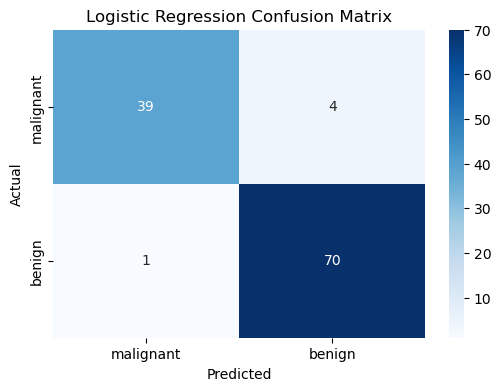

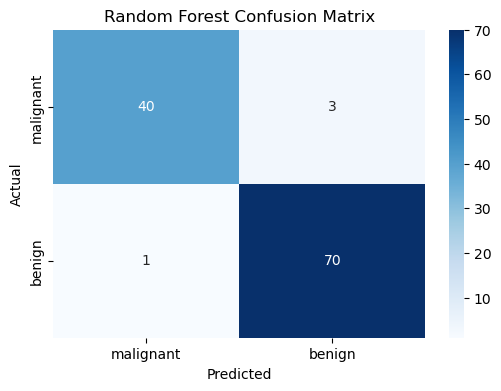

In [14]:
import seaborn as sns

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=data.target_names, 
                yticklabels=data.target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Call the function for both models
plot_confusion_matrix(cm_lr, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(cm_rf, "Random Forest Confusion Matrix")

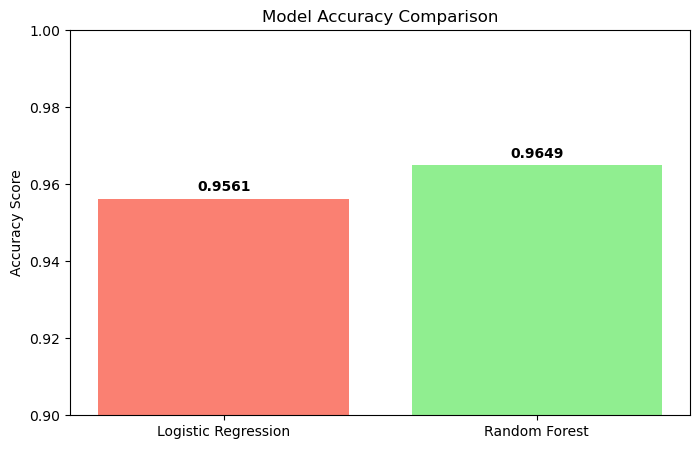

In [15]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy_lr, accuracy_rf]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['salmon', 'lightgreen'])
plt.ylim(0.9, 1.0) # Zoom in to see the difference clearly
plt.ylabel('Accuracy Score')
plt.title('Model Accuracy Comparison')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

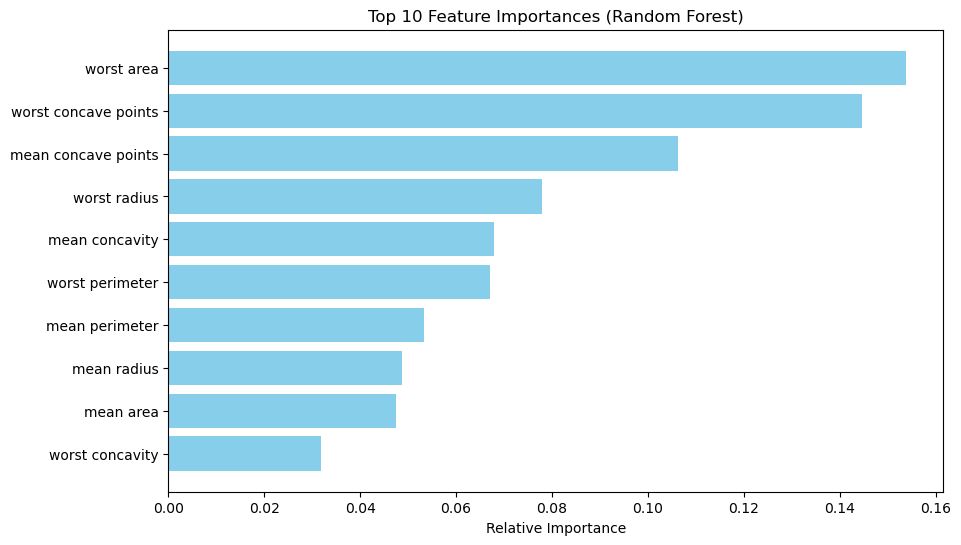

In [16]:
importances = model_rf.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [data.feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# Disease Prediction using Machine Learning

## Objective
To predict whether a tumor is malignant or benign using medical features from the Breast Cancer dataset.

## Dataset
- 569 patient samples
- 30 medical features
- Binary classification (Malignant vs Benign)

## Models Used
1. Logistic Regression (Accuracy: 95.6%)
2. Random Forest (Accuracy: 96.4%)

## Conclusion
Random Forest performed better by achieving higher accuracy and reducing false negatives (missed cancer cases).